## PCA для градиентного бустинга категорий

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
train_data = load_npz("x_train_cat_tfidf.npz")
test_data  = load_npz("x_test_cat_tfidf.npz")

X_train = train_data[:, :-1]
y_train = train_data[:, -1].toarray().ravel().astype(int)

X_test = test_data[:, :-1]
y_test  = test_data[:, -1].toarray().ravel().astype(int)

In [3]:
X_small = X_train[:500]

In [4]:
U, D, Vt = sp.sparse.linalg.svds(X_small, k=10)

In [5]:
U.shape

(500, 10)

In [6]:
D.shape

(10,)

In [7]:
Vt.shape

(10, 50000)

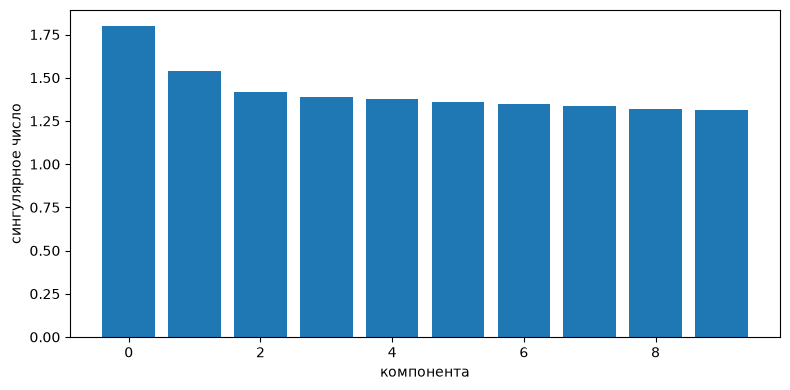

In [8]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(D)), sorted(D, reverse=True))
plt.xlabel("компонента")
plt.ylabel("сингулярное число")
plt.tight_layout()
plt.show()

In [9]:
svd2 = TruncatedSVD(n_components=2, random_state=67)
X_train_2d = svd2.fit_transform(X_train)

In [10]:
le_classes = np.array([
    'ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE',
    'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION',
    'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK',
    'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT',
    'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS',
    'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS',
    'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST',
    'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS',
    'WOMEN', 'WORLD NEWS', 'WORLDPOST'
])

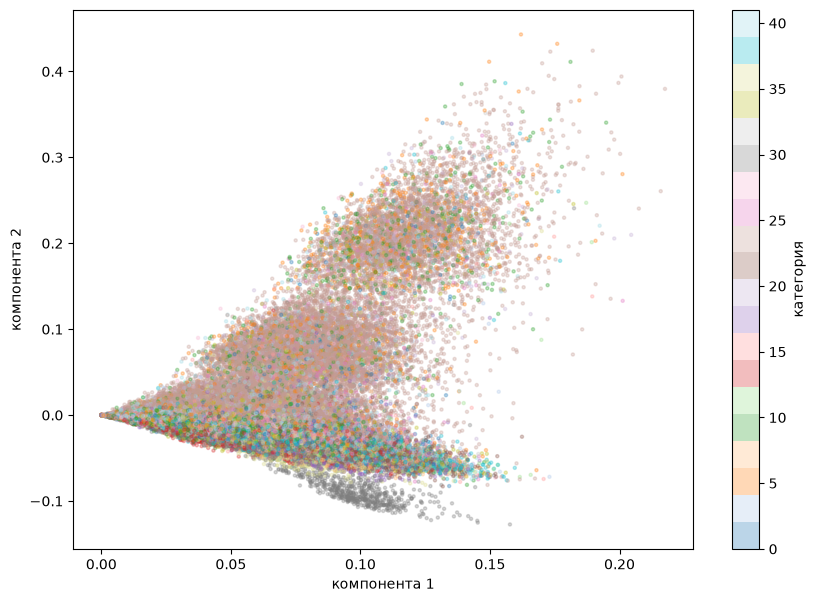

In [11]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=y_train, cmap='tab20', alpha=0.3, s=5)
plt.colorbar(scatter, label='категория')
plt.xlabel("компонента 1")
plt.ylabel("компонента 2")
plt.show()

По графику проекции матрицы на две главные компоненты видно, что категории новостей практически не разделяются — все точки перемешаны в одном облаке, это ожидаемо, так как две компоненты сохраняют очень малую долю исходной информации из 50000 признаков. Исключение составляют несколько категорий с характерной лексикой, которые слегка выделяются на краях облака. Для качественной визуализации и классификации необходимо использовать значительно больше компонент.

In [19]:
svd5000 = TruncatedSVD(n_components=2500, random_state=67, n_iter=1)
svd5000.fit(X_train)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",2500
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",1
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary <random_state>`.",67
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0
Name,Type,Value
"components_ components_: ndarray of shape (n_components, n_features)The right singular vectors of the input data.","ndarray[float64](2500, 50000)","[[ 0., 0., 0.,..., 0., 0., 0.], [-0.,-0.,-0.,...,-0.,-0.,-0.], [-0., 0.,-0.,...,-0.,-0.,-0.], ..., [ 0., 0.,-0.,...,-0., 0., 0.], [ 0., 0.,-0.,...,-0., 0.,-0.], [ 0.,-0., 0.,..., 0., 0.,-0.]]"
"explained_variance_ explained_variance_: ndarray of shape (n_components,)The variance of the training samples transformed by a projection toeach component.","ndarray[float64](2500,)","[0.,0.,0.,...,0.,0.,0.]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.","ndarray[float64](2500,)","[0.,0.,0.,...,0.,0.,0.]"


In [20]:
cumvar = np.cumsum(svd5000.explained_variance_ratio_)
cumvar

array([0.00071082, 0.00304139, 0.00481985, ..., 0.43514276, 0.43519672,
       0.43525046], shape=(2500,))

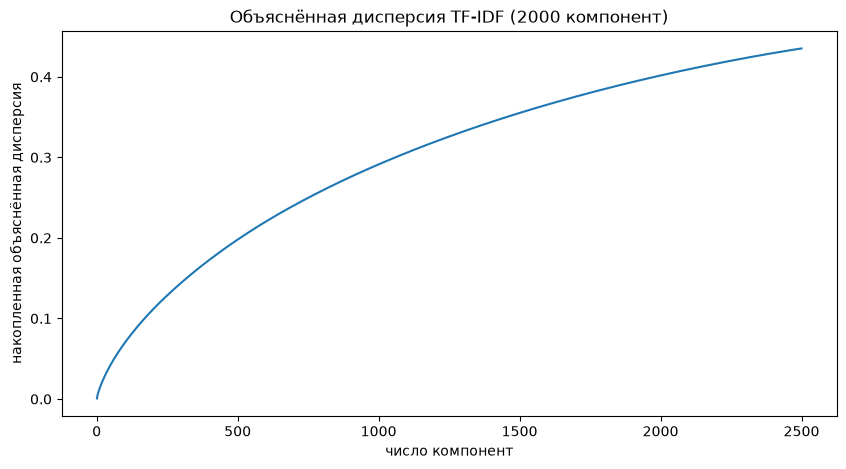

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar)
plt.xlabel("число компонент")
plt.ylabel("накопленная объяснённая дисперсия")
plt.title("Объяснённая дисперсия TF-IDF (2000 компонент)")
plt.show()

In [23]:
X_train_svd = svd5000.transform(X_train)
X_test_svd  = svd5000.transform(X_test)

np.savez("x_train_svd.npz", X=X_train_svd, y=y_train)
np.savez("x_test_svd.npz",  X=X_test_svd,  y=y_test)